# Level 1 · Task 1 — Data Preprocessing for Machine Learning

**Goal:** take the raw `sentiment.csv` dataset and make it fully ready for machine learning.

**What we'll do (as per the task requirements):**
1. Explore the raw data and find quality issues
2. Handle missing data (median fill / dropping)
3. Encode categorical variables (one-hot + label encoding)
4. Normalize/standardize numerical features
5. Split into training and testing sets

*Tools: Python, pandas, scikit-learn*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/sentiment.csv')
print('shape:', df.shape)
df.head()

shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
# quick overview of columns and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [3]:
# missing values and duplicates
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Duplicate rows: 0


In [4]:
# the target column looks messy — let's check
print('unique sentiment labels:', df['Sentiment'].nunique())
print('\na few raw examples:')
print(df['Sentiment'].sample(12, random_state=1).tolist())

unique sentiment labels: 279

a few raw examples:
[' Inspiration  ', ' Excitement ', ' Enthusiasm    ', ' Resilience ', ' Bad ', ' Ambivalence     ', ' Joy ', ' Zest ', ' Anticipation  ', ' Desolation ', ' Fulfillment  ', ' Bitter       ']


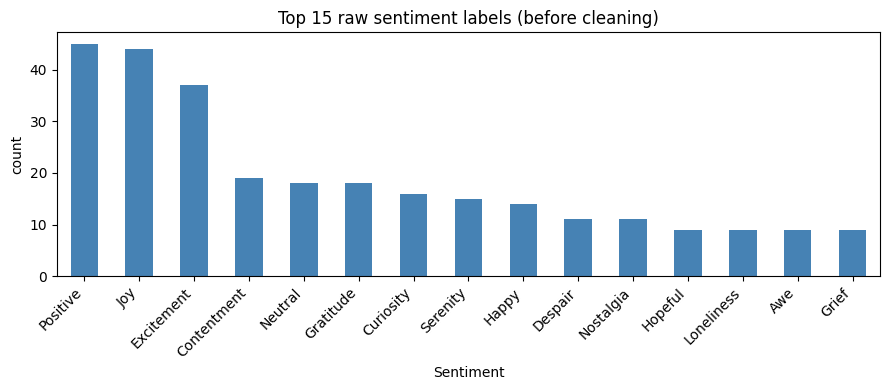

In [5]:
# top 15 most frequent raw labels
top = df['Sentiment'].str.strip().value_counts().head(15)

plt.figure(figsize=(9, 4))
top.plot(kind='bar', color='steelblue')
plt.title('Top 15 raw sentiment labels (before cleaning)')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()